# 🎬 Netflix Titles - Exploratory Data Analysis (EDA)

This notebook explores a dataset of movies and TV shows available on **Netflix**. The goal is to understand the shape and quality of the data, then answer simple questions like:
- Are there more Movies or TV Shows on Netflix?
- Which countries produce the most Netflix content?
- What content ratings (age classifications) are most common?

**Dataset:** `netflix_titles.xlsx` (place this file in the same folder as this notebook)

**Tools used:**
- `pandas` — to load and explore the data
- `matplotlib` — to visualize the results

**Setup:** reading an Excel file with pandas requires the `openpyxl` package. If you get an error, install it with:
```
pip install openpyxl
```


## Step 1: Load the Dataset and Preview It

We load the Excel file into a pandas DataFrame with `pd.read_excel()`, then print the first 5 rows with `.head()` to get a first look at the columns and the kind of data each one holds.


In [1]:
import pandas as pd

df = pd.read_excel("netflix_titles.xlsx")

print("First 5 Rows")
print(df.head())


First 5 Rows
  show_id     type                        title              director  \
0   s5958    Movie         To and From New York  Sorin Dan Mihalcescu   
1   s6612  TV Show              Dinner for Five                   NaN   
2   s5957    Movie      Just Another Love Story          Ole Bornedal   
3   s5956    Movie                     Splatter             Joe Dante   
4   s7371    Movie  Mad Ron's Prevues from Hell            Jim Monaco   

                                                cast        country  \
0  Barbara King, Shaana Diya, John Krisiukenas, Y...  United States   
1                                                NaN  United States   
2  Anders W. Berthelsen, Rebecka Hemse, Nikolaj L...        Denmark   
3  Corey Feldman, Tony Todd, Tara Leigh, Erin Way...  United States   
4  Nick Pawlow, Jordu Schell, Jay Kushwara, Micha...  United States   

            date_added  release_year rating  duration  \
0  2008-01-01 00:00:00          2006  TV-MA    81 min   
1  2008

## Step 2: Check Column Types and Non-Null Counts

`.info()` gives a quick summary of the DataFrame: how many rows it has, each column's data type, and how many non-missing values it contains. This is one of the first things to check in any EDA, since it flags columns that will need cleaning.

**Result:** the dataset has **8,807 rows and 12 columns**. Columns like `director`, `cast`, and `country` clearly have missing values (fewer non-null entries than the total row count), which we'll quantify next.


In [1]:
print("\nDataset Info")
print(df.info())



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


## Step 3: Check the Shape of the Dataset

`.shape` returns `(rows, columns)` — a quick way to confirm the size of the dataset without scrolling through `.info()` output.


In [1]:
print("\nShape")
print(df.shape)



Shape
(8807, 12)


## Step 4: Count Missing Values in Each Column

`.isnull().sum()` counts how many missing (blank) values each column has. This confirms what `.info()` hinted at: `director` is missing in **2,634** rows, `cast` in **825**, and `country` in **831** — these columns would need to be handled carefully (e.g. filled with "Unknown" or dropped) before doing deeper analysis that relies on them.


In [1]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


## Step 5: Check for Duplicate Rows

`.duplicated().sum()` counts how many rows are exact duplicates of an earlier row. Duplicates can skew counts and averages, so it's good practice to check for them early.

**Result:** there are **0 duplicate rows** — the dataset is already clean on this front.


In [1]:
print("\nDuplicate Rows")
print(df.duplicated().sum())



Duplicate Rows
0


## Step 6: Movies vs TV Shows

`.value_counts()` on the `type` column counts how many entries are `"Movie"` versus `"TV Show"`.

**Result:** Netflix's catalog leans heavily toward movies — **6,131 Movies** compared to **2,676 TV Shows**, roughly a 70/30 split.


In [1]:
print("\nMovies vs TV Shows")
print(df['type'].value_counts())



Movies vs TV Shows
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


## Step 7: Top 10 Countries by Number of Titles

We count how many titles come from each country and look at the top 10. Since some titles list multiple co-producing countries as one string, this counts each unique country combination, so the true single-country totals are actually a lower bound — but the ranking still gives a clear picture.

**Result:** the **United States (2,818)** dominates, followed by **India (972)** and the **United Kingdom (419)**.


In [1]:
print("\nTop 10 Countries")
print(df['country'].value_counts().head(10))



Top 10 Countries
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


## Step 8: Content Ratings Breakdown

The `rating` column holds age/content classifications (like `TV-MA`, `PG-13`, `TV-Y`). Counting them shows what kind of audience Netflix's catalog is mostly aimed at.

**Result:** **TV-MA** (mature audiences) is by far the most common rating (3,207 titles), followed by **TV-14** (2,160) and **TV-PG** (863) — confirming Netflix's catalog skews toward mature/adult content overall. A few rows have odd values like `"66 min"` in the rating column — a data entry error where duration values leaked into the ratings field.


In [1]:
print("\nRatings")
print(df['rating'].value_counts())



Ratings
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
66 min         1
84 min         1
74 min         1
Name: count, dtype: int64


## Step 9: Visualize Movies vs TV Shows

A bar chart makes the Movie/TV Show split from Step 6 immediately visible — the height difference clearly shows movies outnumber TV shows on Netflix.


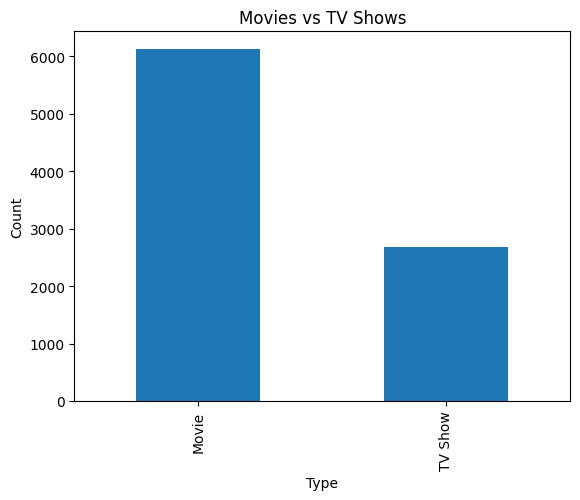

In [1]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()


## Step 10: Visualize the Top 10 Countries

This bar chart plots the top 10 countries from Step 7, making the gap between the United States and every other country immediately obvious.


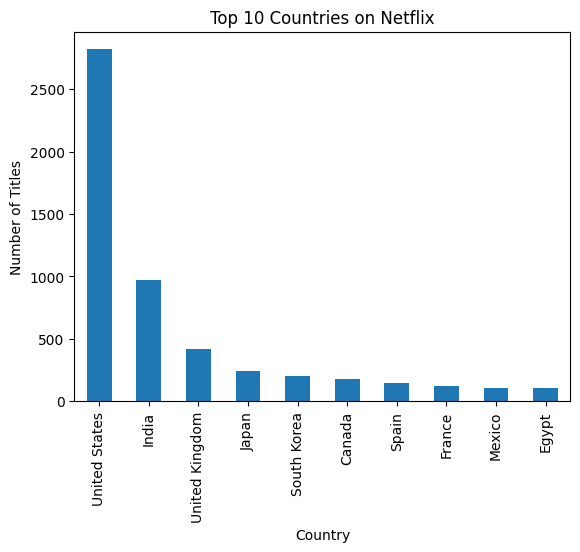

In [1]:
df['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()


## Step 11: Visualize the Top Content Ratings

This bar chart shows the top 10 ratings from Step 8, visually confirming that mature-audience ratings (`TV-MA`, `TV-14`) dominate the catalog.


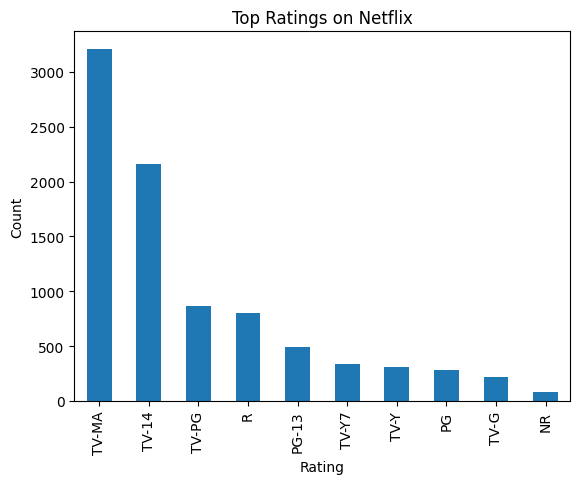

In [1]:
df['rating'].value_counts().head(10).plot(kind='bar')

plt.title("Top Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()


## Summary

In this notebook we:
1. Loaded the Netflix titles dataset (8,807 rows, 12 columns) from Excel
2. Checked data types, missing values, and duplicates
3. Found Netflix's catalog is ~70% Movies and ~30% TV Shows
4. Found the United States, India, and the United Kingdom produce the most titles
5. Found `TV-MA` and `TV-14` are the most common content ratings
6. Visualized each of these findings with bar charts

### Possible next steps
- Fill or drop missing `director`/`cast`/`country` values depending on the analysis goal
- Parse `date_added` into a real datetime column and analyze titles added over time
- Split multi-genre `listed_in` values to analyze genre popularity
